So, let's start with the Titanic Challenge. I'm just learning and I'll try different types of classifiers...

In [1]:
import numpy as np
import pandas as pd 

# Loading the data

In [2]:
df_train = pd.read_csv("/kaggle/input/titanic/train.csv", index_col = 'PassengerId')
df_train.sample(10)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
468,0,1,"Smart, Mr. John Montgomery",male,56.0,0,0,113792,26.5500,NaN,S
594,0,3,"Bourke, Miss. Mary",female,NaN,0,2,364848,7.7500,NaN,Q
228,0,3,"Lovell, Mr. John Hall (""Henry"")",male,20.5,0,0,A/5 21173,7.2500,NaN,S
858,1,1,"Daly, Mr. Peter Denis",male,51.0,0,0,113055,26.5500,E17,S
283,0,3,"de Pelsmaeker, Mr. Alfons",male,16.0,0,0,345778,9.5000,NaN,S
401,1,3,"Niskanen, Mr. Juha",male,39.0,0,0,STON/O 2. 3101289,7.9250,NaN,S
872,1,1,"Beckwith, Mrs. Richard Leonard (Sallie Monypeny)",female,47.0,1,1,11751,52.5542,D35,S
117,0,3,"Connors, Mr. Patrick",male,70.5,0,0,370369,7.7500,NaN,Q
773,0,2,"Mack, Mrs. (Mary)",female,57.0,0,0,S.O./P.P. 3,10.5000,E77,S


In [3]:
df_test = pd.read_csv("/kaggle/input/titanic/test.csv", index_col = 'PassengerId')
df_test.sample(10)

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,
986,1,"Birnbaum, Mr. Jakob",male,25.0,0,0,13905,26.0000,NaN,C
1158,1,"Chisholm, Mr. Roderick Robert Crispin",male,NaN,0,0,112051,0.0000,NaN,S
943,2,"Pulbaum, Mr. Franz",male,27.0,0,0,SC/PARIS 2168,15.0333,NaN,C
1292,1,"Bonnell, Miss. Caroline",female,30.0,0,0,36928,164.8667,C7,S
1304,3,"Henriksson, Miss. Jenny Lovisa",female,28.0,0,0,347086,7.7750,NaN,S
1229,3,"Elias, Mr. Joseph",male,39.0,0,2,2675,7.2292,NaN,C
1123,1,"Willard, Miss. Constance",female,21.0,0,0,113795,26.5500,NaN,S
944,2,"Hocking, Miss. Ellen Nellie""""",female,20.0,2,1,29105,23.0000,NaN,S
1119,3,"McNeill, Miss. Bridget",female,NaN,0,0,370368,7.7500,NaN,Q


# EDA

In [4]:
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [5]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB


In [6]:
df_train.isna().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      2
dtype: int64

<AxesSubplot:ylabel='PassengerId'>

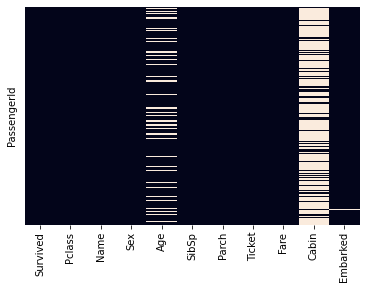

In [7]:
# from https://medium.datadriveninvestor.com/step-by-step-exploratory-data-analysis-of-titanic-dataset-2d0fb09b0e86
sns.heatmap(df_train.isnull(),yticklabels=False,cbar=False)

So, the columns 'Age', 'Embarked' and 'Cabin' have missing values (and Cabin is missing for more than 3/4 of the passengers, in fact)

In [8]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 418 entries, 892 to 1309
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    418 non-null    int64  
 1   Name      418 non-null    object 
 2   Sex       418 non-null    object 
 3   Age       332 non-null    float64
 4   SibSp     418 non-null    int64  
 5   Parch     418 non-null    int64  
 6   Ticket    418 non-null    object 
 7   Fare      417 non-null    float64
 8   Cabin     91 non-null     object 
 9   Embarked  418 non-null    object 
dtypes: float64(2), int64(3), object(5)
memory usage: 35.9+ KB


In [9]:
for col in ['Survived', 'Pclass', 'Sex']:
    print(df_train[[col]].value_counts())

Survived
0           549
1           342
dtype: int64
Pclass
3         491
1         216
2         184
dtype: int64
Sex   
male      577
female    314
dtype: int64


Let's look at titles

In [10]:
df_train['Title'] = df_train['Name'].str.extract('([A-Za-z]+)\.')
df_train

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
PassengerId,,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr
...,...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,Rev
888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,Miss
889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,Miss


In [11]:
df_test['Title'] = df_test['Name'].str.extract('([A-Za-z]+)\.')
df_test

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
PassengerId,,,,,,,,,,,
892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,Mr
893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,Mrs
894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,Mr
895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,Mr
896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,Mrs
...,...,...,...,...,...,...,...,...,...,...,...
1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S,Mr
1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C,Dona
1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,Mr


In [12]:
df_train['Title'].value_counts()

Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Mlle          2
Major         2
Col           2
Countess      1
Capt          1
Ms            1
Sir           1
Lady          1
Mme           1
Don           1
Jonkheer      1
Name: Title, dtype: int64

In [13]:
df_train.loc[df_train['Title'].isin(['Master'])]

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
PassengerId,,,,,,,,,,,,
8,0,3,"Palsson, Master. Gosta Leonard",male,2.00,3,1,349909,21.0750,NaN,S,Master
17,0,3,"Rice, Master. Eugene",male,2.00,4,1,382652,29.1250,NaN,Q,Master
51,0,3,"Panula, Master. Juha Niilo",male,7.00,4,1,3101295,39.6875,NaN,S,Master
60,0,3,"Goodwin, Master. William Frederick",male,11.00,5,2,CA 2144,46.9000,NaN,S,Master
64,0,3,"Skoog, Master. Harald",male,4.00,3,2,347088,27.9000,NaN,S,Master
66,1,3,"Moubarek, Master. Gerios",male,NaN,1,1,2661,15.2458,NaN,C,Master
79,1,2,"Caldwell, Master. Alden Gates",male,0.83,0,2,248738,29.0000,NaN,S,Master
126,1,3,"Nicola-Yarred, Master. Elias",male,12.00,1,0,2651,11.2417,NaN,C,Master
160,0,3,"Sage, Master. Thomas Henry",male,NaN,8,2,CA. 2343,69.5500,NaN,S,Master


In [14]:
df_train.loc[df_train['Title'] == 'Master']['Age'].max()

12.0

In [15]:
df_train.loc[df_train['Title'] == 'Mr']['Age'].min()

11.0

So, 'Master' is a title for young boys.

In [16]:
df_train.loc[df_train['Title'].isin(['Dr', 'Rev', 'Jonkheer'])]

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
PassengerId,,,,,,,,,,,,
150,0,2,"Byles, Rev. Thomas Roussel Davids",male,42.0,0,0,244310,13.0000,NaN,S,Rev
151,0,2,"Bateman, Rev. Robert James",male,51.0,0,0,S.O.P. 1166,12.5250,NaN,S,Rev
246,0,1,"Minahan, Dr. William Edward",male,44.0,2,0,19928,90.0000,C78,Q,Dr
250,0,2,"Carter, Rev. Ernest Courtenay",male,54.0,1,0,244252,26.0000,NaN,S,Rev
318,0,2,"Moraweck, Dr. Ernest",male,54.0,0,0,29011,14.0000,NaN,S,Dr
399,0,2,"Pain, Dr. Alfred",male,23.0,0,0,244278,10.5000,NaN,S,Dr
627,0,2,"Kirkland, Rev. Charles Leonard",male,57.0,0,0,219533,12.3500,NaN,Q,Rev
633,1,1,"Stahelin-Maeglin, Dr. Max",male,32.0,0,0,13214,30.5000,B50,C,Dr
661,1,1,"Frauenthal, Dr. Henry William",male,50.0,2,0,PC 17611,133.6500,NaN,S,Dr


Wikipedia: Jonkheer (female equivalent: jonkvrouw; French: Écuyer; English: Squire) is an honorific in the Low Countries denoting the lowest rank within the nobility. In the Netherlands, this in general concerns a prefix used by the untitled nobility. In Belgium, this is the lowest title within the nobility system, recognised by the Court of Cassation.

In [17]:
df_train.loc[df_train['Title'].isin(['Major', 'Col', 'Capt'])]

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
PassengerId,,,,,,,,,,,,
450,1,1,"Peuchen, Major. Arthur Godfrey",male,52.0,0,0,113786,30.50,C104,S,Major
537,0,1,"Butt, Major. Archibald Willingham",male,45.0,0,0,113050,26.55,B38,S,Major
648,1,1,"Simonius-Blumer, Col. Oberst Alfons",male,56.0,0,0,13213,35.50,A26,C,Col
695,0,1,"Weir, Col. John",male,60.0,0,0,113800,26.55,NaN,S,Col
746,0,1,"Crosby, Capt. Edward Gifford",male,70.0,1,1,WE/P 5735,71.00,B22,S,Capt


In [18]:
df_test['Title'].value_counts()

Mr        240
Miss       78
Mrs        72
Master     21
Col         2
Rev         2
Ms          1
Dr          1
Dona        1
Name: Title, dtype: int64

In [19]:
df_test.loc[df_test['Title'].isin(['Dr', 'Rev', 'Dona'])]

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
PassengerId,,,,,,,,,,,
1041,2,"Lahtinen, Rev. William",male,30.0,1,1,250651,26.0000,NaN,S,Rev
1056,2,"Peruschitz, Rev. Joseph Maria",male,41.0,0,0,237393,13.0000,NaN,S,Rev
1185,1,"Dodge, Dr. Washington",male,53.0,1,1,33638,81.8583,A34,S,Dr
1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C,Dona


# (Attempt of) feature engineering

In [20]:
# idea from CORAZON17 
def convert_title(title):
    if title in ["Ms", "Mlle", "Miss"]:
        return "Miss"
    elif title in ["Mme", "Mrs", "Countess", "Lady", "Dona"]:
        return "Mrs"
    elif title in ["Mr", "Major", "Col", "Capt", "Sir", "Don", "Jonkheer"]:
        return "Mr"
    elif title == "Master":
        return "Master"
    elif title == "Rev":
        return "Rev"
    else:
        return title       


In [21]:
y_train = df_train.Survived
X_train_full = df_train.drop(['Survived'], axis=1)
X_train = X_train_full.drop(['Name','Ticket', 'Cabin'], axis=1)
X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title
PassengerId,,,,,,,,
1,3,male,22.0,1,0,7.2500,S,Mr
2,1,female,38.0,1,0,71.2833,C,Mrs
3,3,female,26.0,0,0,7.9250,S,Miss
4,1,female,35.0,1,0,53.1000,S,Mrs
5,3,male,35.0,0,0,8.0500,S,Mr
...,...,...,...,...,...,...,...,...
887,2,male,27.0,0,0,13.0000,S,Rev
888,1,female,19.0,0,0,30.0000,S,Miss
889,3,female,NaN,1,2,23.4500,S,Miss


In [22]:
X_train.isna().sum()

Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
Title         0
dtype: int64

In [23]:
X_test = df_test.drop(['Name','Ticket', 'Cabin'], axis=1)
X_test

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title
PassengerId,,,,,,,,
892,3,male,34.5,0,0,7.8292,Q,Mr
893,3,female,47.0,1,0,7.0000,S,Mrs
894,2,male,62.0,0,0,9.6875,Q,Mr
895,3,male,27.0,0,0,8.6625,S,Mr
896,3,female,22.0,1,1,12.2875,S,Mrs
...,...,...,...,...,...,...,...,...
1305,3,male,NaN,0,0,8.0500,S,Mr
1306,1,female,39.0,0,0,108.9000,C,Dona
1307,3,male,38.5,0,0,7.2500,S,Mr


In [24]:
X_train["Title"] = df_train["Title"].map(convert_title)
X_train["Title"].value_counts()


Mr        525
Miss      185
Mrs       128
Master     40
Dr          7
Rev         6
Name: Title, dtype: int64

In [25]:
X_test["Title"] = df_test["Title"].map(convert_title)
X_test["Title"].value_counts()

Mr        242
Miss       79
Mrs        73
Master     21
Rev         2
Dr          1
Name: Title, dtype: int64

In [26]:
for title in X_train["Title"].value_counts().keys():
    m = X_train[X_train["Title"]==title]['Age'].median()
    print(title, m)
    X_train.loc[(X_train.Age.isnull()) & (X_train["Title"]==title), 'Age'] = m
    X_test.loc[(X_test.Age.isnull()) & (X_test["Title"]==title), 'Age'] = m



Mr 30.0
Miss 21.0
Mrs 35.0
Master 3.5
Dr 46.5
Rev 46.5


In [27]:
X_train.isna().sum()

Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    2
Title       0
dtype: int64

In [28]:
X_test.isna().sum()

Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        1
Embarked    0
Title       0
dtype: int64

In [29]:
X_train['Embarked'].fillna(value=X_train['Embarked'].mode()[0],inplace=True)


In [30]:
#X_train['FareLog'] = np.log(X_train['Fare'] + 1)
#X_test['FareLog'] = np.log(X_test['Fare'] + 1)
#X_train.drop(['Fare'], axis=1, inplace=True)
#X_test.drop(['Fare'], axis=1, inplace=True)

In [31]:
X_test.loc[(X_test['Fare'].isnull())]

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title
PassengerId,,,,,,,,
1044,3,male,60.5,0,0,NaN,S,Mr


In [32]:
X_test.loc[(X_test['Fare'].isnull()), 'Fare'] = X_train.loc[(X_train['Pclass']==3)]['Fare'].median()

In [33]:
X_train.isna().sum()

Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
Title       0
dtype: int64

In [34]:
X_test.isna().sum()

Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
Title       0
dtype: int64

In [35]:
# some ideas from others' notebooks
#X_train['FamilySize'] = X_train['SibSp'] + X_train['Parch']
#X_train.drop(['SibSp', 'Parch'], axis=1, inplace=True)
#X_train['AgePclass'] =  X_train['Age'] * X_train['Pclass']
#X_test['AgePclass'] =  X_test['Age'] * X_test['Pclass']


In [36]:
X_train = pd.get_dummies(X_train)
X_train

,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Title_Dr,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Rev
PassengerId,,,,,,,,,,,,,,,,
1,3,22.0,1,0,7.2500,0,1,0,0,1,0,0,0,1,0,0
2,1,38.0,1,0,71.2833,1,0,1,0,0,0,0,0,0,1,0
3,3,26.0,0,0,7.9250,1,0,0,0,1,0,0,1,0,0,0
4,1,35.0,1,0,53.1000,1,0,0,0,1,0,0,0,0,1,0
5,3,35.0,0,0,8.0500,0,1,0,0,1,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
887,2,27.0,0,0,13.0000,0,1,0,0,1,0,0,0,0,0,1
888,1,19.0,0,0,30.0000,1,0,0,0,1,0,0,1,0,0,0
889,3,21.0,1,2,23.4500,1,0,0,0,1,0,0,1,0,0,0


In [37]:
X_test = pd.get_dummies(X_test)
X_test

,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Title_Dr,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Rev
PassengerId,,,,,,,,,,,,,,,,
892,3,34.5,0,0,7.8292,0,1,0,1,0,0,0,0,1,0,0
893,3,47.0,1,0,7.0000,1,0,0,0,1,0,0,0,0,1,0
894,2,62.0,0,0,9.6875,0,1,0,1,0,0,0,0,1,0,0
895,3,27.0,0,0,8.6625,0,1,0,0,1,0,0,0,1,0,0
896,3,22.0,1,1,12.2875,1,0,0,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1305,3,30.0,0,0,8.0500,0,1,0,0,1,0,0,0,1,0,0
1306,1,39.0,0,0,108.9000,1,0,1,0,0,0,0,0,0,1,0
1307,3,38.5,0,0,7.2500,0,1,0,0,1,0,0,0,1,0,0


# Random Forest

In [38]:
from sklearn.model_selection import KFold, cross_val_score

from sklearn.ensemble import RandomForestClassifier

best_parameters = 0, 0
best_score = 0

kf = KFold(n_splits=5, shuffle=True, random_state=42)
for k in range(100, 500, 100):
    for d in range(5, 20, 5):
        print(f'Number of trees = {k}, max depth = {d}')    
        clf = RandomForestClassifier(n_estimators=k, max_depth=d, random_state=42)
        score = round(cross_val_score(clf, X_train, y_train, cv = kf, scoring='accuracy').mean(), 3)
        print(f'Accuracy = {score}')
        if score > best_score:
            best_score = score
            best_parameters = k, d            


Number of trees = 100, max depth = 5
Accuracy = 0.831
Number of trees = 100, max depth = 10
Accuracy = 0.832
Number of trees = 100, max depth = 15
Accuracy = 0.829
Number of trees = 200, max depth = 5
Accuracy = 0.832
Number of trees = 200, max depth = 10
Accuracy = 0.833
Number of trees = 200, max depth = 15
Accuracy = 0.825
Number of trees = 300, max depth = 5
Accuracy = 0.831
Number of trees = 300, max depth = 10
Accuracy = 0.833
Number of trees = 300, max depth = 15
Accuracy = 0.826
Number of trees = 400, max depth = 5
Accuracy = 0.829
Number of trees = 400, max depth = 10
Accuracy = 0.832
Number of trees = 400, max depth = 15
Accuracy = 0.823


In [39]:
best_score, best_parameters

(0.833, (200, 10))

In [40]:
clf_rf = RandomForestClassifier(n_estimators=best_parameters[0], max_depth=best_parameters[1], random_state=42)
clf_rf.fit(X_train, y_train)
predictions_rf = clf_rf.predict(X_test)

In [41]:
output_rf = pd.DataFrame({'PassengerId': df_test.index, 'Survived': predictions_rf})
output_rf.to_csv('submission_rf.csv', index=False)
print("Your submission was successfully saved!")

Your submission was successfully saved!


# Logistic Regression

In [42]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_train_scaled

array([[ 0.82737724, -0.55741976,  0.43279337, ...,  0.83495081,
        -0.40958375, -0.0823387 ],
       [-1.56610693,  0.64941006,  0.43279337, ..., -1.19767534,
         2.44150312, -0.0823387 ],
       [ 0.82737724, -0.25571231, -0.4745452 , ..., -1.19767534,
        -0.40958375, -0.0823387 ],
       ...,
       [ 0.82737724, -0.63284663,  0.43279337, ..., -1.19767534,
        -0.40958375, -0.0823387 ],
       [-1.56610693, -0.25571231, -0.4745452 , ...,  0.83495081,
        -0.40958375, -0.0823387 ],
       [ 0.82737724,  0.19684888, -0.4745452 , ...,  0.83495081,
        -0.40958375, -0.0823387 ]])

In [43]:
X_test_scaled = scaler.transform(X_test)
X_test_scaled

array([[ 0.82737724,  0.38541604, -0.4745452 , ...,  0.83495081,
        -0.40958375, -0.0823387 ],
       [ 0.82737724,  1.32825184,  0.43279337, ..., -1.19767534,
         2.44150312, -0.0823387 ],
       [-0.36936484,  2.4596548 , -0.4745452 , ...,  0.83495081,
        -0.40958375, -0.0823387 ],
       ...,
       [ 0.82737724,  0.6871235 , -0.4745452 , ...,  0.83495081,
        -0.40958375, -0.0823387 ],
       [ 0.82737724,  0.04599515, -0.4745452 , ...,  0.83495081,
        -0.40958375, -0.0823387 ],
       [ 0.82737724, -1.95281675,  0.43279337, ..., -1.19767534,
        -0.40958375, -0.0823387 ]])

In [44]:
from sklearn.linear_model import LogisticRegression
best_coeff = 0
best_score = 0
for reg_coeff in [0.1, 1, 5, 10, 20, 50, 100, 500, 1000]:
    print(f'Regularization coefficient = {reg_coeff}')    
    clf = LogisticRegression(penalty='l2', C=reg_coeff, random_state=42)
    score = round(cross_val_score(clf, X_train_scaled, y_train, cv = kf, scoring='accuracy').mean(), 3)
    print(f'Accuracy = {score}')
    if score > best_score:
        best_score, best_coeff = score, reg_coeff


Regularization coefficient = 0.1
Accuracy = 0.828
Regularization coefficient = 1
Accuracy = 0.825
Regularization coefficient = 5
Accuracy = 0.826
Regularization coefficient = 10
Accuracy = 0.826
Regularization coefficient = 20
Accuracy = 0.826
Regularization coefficient = 50
Accuracy = 0.826
Regularization coefficient = 100
Accuracy = 0.826
Regularization coefficient = 500
Accuracy = 0.826
Regularization coefficient = 1000
Accuracy = 0.826


In [45]:
best_score, best_coeff

(0.828, 0.1)

In [46]:
clf_lr = LogisticRegression(penalty='l2', C=best_coeff, random_state=42)
clf_lr.fit(X_train_scaled, y_train)
predictions_lr = clf_lr.predict(X_test_scaled)


In [47]:
output_lr = pd.DataFrame({'PassengerId': df_test.index, 'Survived': predictions_lr})
output_lr.to_csv('submission_log.csv', index=False)
print("Your submission was successfully saved!")

Your submission was successfully saved!


(Gives the best score on test set now, 0.77511)

Logistic regression requires features to be independent (https://towardsdatascience.com/assumptions-of-logistic-regression-clearly-explained-44d85a22b290#:~:text=Logistic%20regression%20does%20not%20require,but%20not%20for%20logistic%20regression), but can we say this about 'Sex' and 'Title' It seems we cannot: after get_dummies, we have X_train['Sex_female'] = X_train['Title_Miss'] + X_train['Title_Mrs'] (okay, there is also one female Dr.) and X_train['Sex_male'] is the sum of the columns corresponding to other titles. Title, in fact (with a single exception), gives us information about a passenger's sex. So, let's drop dependent columns and look at the result.

In [48]:
X_train_scaled_independent = scaler.fit_transform(X_train.drop(columns=['Sex_female', 'Sex_male']))
X_train_scaled_independent

array([[ 0.82737724, -0.55741976,  0.43279337, ...,  0.83495081,
        -0.40958375, -0.0823387 ],
       [-1.56610693,  0.64941006,  0.43279337, ..., -1.19767534,
         2.44150312, -0.0823387 ],
       [ 0.82737724, -0.25571231, -0.4745452 , ..., -1.19767534,
        -0.40958375, -0.0823387 ],
       ...,
       [ 0.82737724, -0.63284663,  0.43279337, ..., -1.19767534,
        -0.40958375, -0.0823387 ],
       [-1.56610693, -0.25571231, -0.4745452 , ...,  0.83495081,
        -0.40958375, -0.0823387 ],
       [ 0.82737724,  0.19684888, -0.4745452 , ...,  0.83495081,
        -0.40958375, -0.0823387 ]])

In [49]:
X_test_scaled_independent = scaler.transform(X_test.drop(columns=['Sex_female', 'Sex_male']))
X_test_scaled_independent

array([[ 0.82737724,  0.38541604, -0.4745452 , ...,  0.83495081,
        -0.40958375, -0.0823387 ],
       [ 0.82737724,  1.32825184,  0.43279337, ..., -1.19767534,
         2.44150312, -0.0823387 ],
       [-0.36936484,  2.4596548 , -0.4745452 , ...,  0.83495081,
        -0.40958375, -0.0823387 ],
       ...,
       [ 0.82737724,  0.6871235 , -0.4745452 , ...,  0.83495081,
        -0.40958375, -0.0823387 ],
       [ 0.82737724,  0.04599515, -0.4745452 , ...,  0.83495081,
        -0.40958375, -0.0823387 ],
       [ 0.82737724, -1.95281675,  0.43279337, ..., -1.19767534,
        -0.40958375, -0.0823387 ]])

In [50]:
from sklearn.linear_model import LogisticRegression
best_coeff = 0
best_score = 0
for reg_coeff in [0.1, 1, 5, 10, 20, 50, 100, 500, 1000]:
    print(f'Regularization coefficient = {reg_coeff}')    
    clf = LogisticRegression(penalty='l2', C=reg_coeff, random_state=42)
    score = round(cross_val_score(clf, X_train_scaled_independent, y_train, cv = kf, scoring='accuracy').mean(), 3)
    print(f'Accuracy = {score}')
    if score > best_score:
        best_score, best_coeff = score, reg_coeff

Regularization coefficient = 0.1
Accuracy = 0.827
Regularization coefficient = 1
Accuracy = 0.824
Regularization coefficient = 5
Accuracy = 0.825
Regularization coefficient = 10
Accuracy = 0.825
Regularization coefficient = 20
Accuracy = 0.825
Regularization coefficient = 50
Accuracy = 0.825
Regularization coefficient = 100
Accuracy = 0.825
Regularization coefficient = 500
Accuracy = 0.825
Regularization coefficient = 1000
Accuracy = 0.825


In [51]:
best_score, best_coeff

(0.827, 0.1)

In [52]:
clf_lr2 = LogisticRegression(penalty='l2', C=best_coeff, random_state=42)
clf_lr2.fit(X_train_scaled_independent, y_train)
predictions_lr2 = clf_lr2.predict(X_test_scaled_independent)

In [53]:
output_lr2 = pd.DataFrame({'PassengerId': df_test.index, 'Survived': predictions_lr2})
output_lr2.to_csv('submission_log_ind.csv', index=False)
print("Your submission was successfully saved!")

Your submission was successfully saved!


Test score is 0.77272 -- even a bit worse than with dependent columns..

# KNN

In [54]:
from sklearn.neighbors import KNeighborsClassifier

best_score = 0
best_k = 0
M = 50
for k in range(1, M, 2):
    clf = KNeighborsClassifier(n_neighbors=k)
    score = cross_val_score(clf, X_train_scaled, y_train, cv=kf, scoring='accuracy').mean()
    print(f'{k}: Accuracy = {score}') 
    if score > best_score:
        best_score = score
        best_k = k

1: Accuracy = 0.7552947084301048
3: Accuracy = 0.8035842068922227
5: Accuracy = 0.8103195028560666
7: Accuracy = 0.8271671583704727
9: Accuracy = 0.8237963718536188
11: Accuracy = 0.8226727763480006
13: Accuracy = 0.8294269035214363
15: Accuracy = 0.8260561170045824
17: Accuracy = 0.8226853304877284
19: Accuracy = 0.8226853304877284
21: Accuracy = 0.8226978846274559
23: Accuracy = 0.8249450756386919
25: Accuracy = 0.8204381394764922
27: Accuracy = 0.8170673529596384
29: Accuracy = 0.8125855250768941
31: Accuracy = 0.8092147385600402
33: Accuracy = 0.8092147385600402
35: Accuracy = 0.8103320569957944
37: Accuracy = 0.8125792480070302
39: Accuracy = 0.8069612704789403
41: Accuracy = 0.8035967610319503
43: Accuracy = 0.8024731655263322
45: Accuracy = 0.7991149331492059
47: Accuracy = 0.797991337643588
49: Accuracy = 0.7968677421379701


In [55]:
best_score, best_k

(0.8294269035214363, 13)

In [56]:
clf_knn = KNeighborsClassifier(n_neighbors=best_k)
clf_knn.fit(X_train_scaled, y_train)
predictions_knn = clf_knn.predict(X_test_scaled)


In [57]:
output_knn = pd.DataFrame({'PassengerId': df_test.index, 'Survived': predictions_knn})
output_knn.to_csv('submission_knn.csv', index=False)
print("Your submission was successfully saved!")

Your submission was successfully saved!


# XGB

In [58]:
from xgboost import XGBClassifier

best_score = 0
best_k = 0

for k in range(100, 1000, 200):
    print(f'{k} models')
    clf = XGBClassifier(n_estimators=k, learning_rate=0.05, n_jobs=4)
    clf.fit(X_train, y_train)
    score = cross_val_score(clf, X_train, y_train, cv=kf, scoring='accuracy').mean()
    print(f'{k}: Accuracy = {score}')
    if score > best_score:
        best_score = score
        best_k = k
    

100 models
100: Accuracy = 0.8327788588286987
300 models
300: Accuracy = 0.8215366267026551
500 models
500: Accuracy = 0.819295712761283
700 models
700: Accuracy = 0.8125729709371665
900 models
900: Accuracy = 0.8114305442219572


In [59]:
best_score, best_k

(0.8327788588286987, 100)

In [60]:
clf_xgb = XGBClassifier(n_estimators=best_k, learning_rate=0.05, n_jobs=4)
clf_xgb.fit(X_train, y_train)
predictions_xgb = clf_xgb.predict(X_test)


In [61]:
output_xgb = pd.DataFrame({'PassengerId': df_test.index, 'Survived': predictions_xgb})
output_xgb.to_csv('submission_xgb.csv', index=False)
print("Your submission was successfully saved!")

Your submission was successfully saved!


# Support Vectors

In [62]:
from sklearn.svm import SVC

for g in ['auto', 'scale']:
    clf = SVC(gamma=g)
    clf.fit(X_train, y_train)
    score = cross_val_score(clf, X_train_scaled, y_train, cv=kf, scoring='accuracy').mean()
    print(f'{g}: Accuracy = {score}')

auto: Accuracy = 0.827185989580064
scale: Accuracy = 0.8283095850856821


Almost no difference...

In [63]:
clf_svc = SVC(probability=True)
clf_svc.fit(X_train_scaled, y_train)
predictions_svc = clf_svc.predict(X_test_scaled)

In [64]:
output_svc = pd.DataFrame({'PassengerId': df_test.index, 'Survived': predictions_svc})
output_svc.to_csv('submission_svc.csv', index=False)
print("Your submission was successfully saved!")

Your submission was successfully saved!


(Yeah, score of 0.78468 !)

# Voting Classifier
Combine the results of all previously used classifiers (idea from https://www.kaggle.com/code/koustavghosh149/a-simple-approach-to-titanic-dataset-83-2-accuracy)

In [65]:
from sklearn.ensemble import VotingClassifier
voting_clf =  VotingClassifier(estimators=
                               [('knn', clf_knn), ('lr', clf_lr), ('svc', clf_svc)], 
                               voting='soft')

In [66]:
voting_clf.fit(X_train_scaled, y_train)

VotingClassifier(estimators=[('knn', KNeighborsClassifier(n_neighbors=13)),
                             ('lr', LogisticRegression(C=0.1, random_state=42)),
                             ('svc', SVC(probability=True))],
                 voting='soft')

In [67]:
predictions = voting_clf.predict(X_test_scaled)
output = pd.DataFrame({'PassengerId': df_test.index, 'Survived': predictions})
output.to_csv('submission_voting.csv', index=False)
print("Your submission was successfully saved!")

Your submission was successfully saved!
